# Multiple topic labels

**Recipe 06** · Level 1 (Beginner) · Decision type: `Noul`

Tag customer feedback with every applicable topic by asking an independent yes-or-no question for each predefined label.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

Tag a piece of customer feedback with every topic it actually raises, from a fixed list of five labels: `pricing`, `reliability`, `usability`, `support`, `feature_request`. Jev answers one independent `Noul` per label — a statement that can be true or false, not a question — about whether the feedback raises that topic, and all five go to the model together in a single request, because they all describe the same state. Python builds the five propositions from the label list, turns the five yes-or-no answers into a tag set using a threshold chosen separately for each label, and sends any label it is not confident enough about to an explicit review outcome instead of guessing. By the end you will have looked at feedback that raises no topic, feedback that only looks like it raises one, and feedback that raises three at once, then run an evaluation that reports per-label precision and recall, a micro and a macro F1, and the share of examples tagged exactly right.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same five question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    evaluate_outcomes,
    exact_set_match,
    multilabel_from_noul,
    multilabel_metrics,
    pool_label_decisions,
    pool_label_outcomes,
    select_confidence_threshold,
    select_threshold,
    selective_curve,
    threshold_sweep,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_risk_coverage,
    plot_threshold_sweep,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
LABELS = list(helpers.LABELS)
examples = load_inputs()
by_id = {e.id: e for e in examples}
labels = load_labels()  # {id: list of gold topic labels, [] when none apply}
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()

# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded
# or live run must not print a bare validation number as if it were a reported result.
selection = " (a selection step, not a reported result)"

# All five labels describe the same feedback text, so every example needs exactly one request
# (see "The questions"), never five. This cache makes sure an example shown individually and
# later scored in its split is decided once: the whole notebook makes exactly 40 requests, one
# per example in fixtures/, not 40 * 5 = 200 (that figure is the number of *decisions* inside
# those requests, one Noul answer per label; see the README's live section).
_decided = {}


def decide(example):
    if example.id not in _decided:
        _decided[example.id] = backend.decide(helpers.build_state(example.fields), questions)
    return _decided[example.id]


run_header(6, "Multiple topic labels", backend=backend, n_examples=len(scored))

Recipe 06: Multiple topic labels
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `feedback_id` and the feedback `text`. `build_state` passes on the text only; the identifier stays in Python and is attached to every outcome, so it never passes through the model and every result still traces back to its feedback.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-mixed3"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "feedback_id": "FB-301",
  "text": "The checkout flow is clunky and the renewal price went up without warning, and now I can't reach anyone on support."
}
Jev sees:
{
  "text": "The checkout flow is clunky and the renewal price went up without warning, and now I can't reach anyone on support."
}


## The questions

Five independent `Noul` propositions, one per label in `helpers.LABELS`, built by a single Python loop over that fixed list. Each proposition is a statement that can be true or false ("The feedback is about ..."), not a question, as CONTRIBUTING.md requires. A `Choice` would not fit here: `Choice` commits to exactly one option, and these five outcomes are not exclusive — a single piece of feedback can raise `pricing` and `reliability` at once, or neither, which is exactly what the catalog's use case for this recipe asks for ("every applicable topic").

All five questions describe the same feedback text, so `backend.decide` sends them together in a single request: TypeSafe's primitives page (S02) says independent questions over the same state belong in one request. A `Noul` has no confidence field at all (S03): the probability of yes, `noul`, is the only number it returns, so every threshold below — one business threshold per label, and one shared confidence cutoff — is chosen from examples, never read directly off the answer.

In [3]:
for label, question in questions.items():
    print(f"{label}:")
    print(f"  instructions: {question.instructions}")
    for side, text in question.criteria.items():
        print(f"    {side}: {text}")

pricing:
  instructions: The feedback is about the price, a charge, a subscription cost, or a refund tied to money.
    true: The feedback is about the price, a charge, a subscription cost, or a refund tied to money.
    false: The feedback does not raise this topic at all.
reliability:
  instructions: The feedback is about the product crashing, an error, downtime, or something not working as built.
    true: The feedback is about the product crashing, an error, downtime, or something not working as built.
    false: The feedback does not raise this topic at all.
usability:
  instructions: The feedback is about how easy or hard the product is to learn, use, or navigate.
    true: The feedback is about how easy or hard the product is to learn, use, or navigate.
    false: The feedback does not raise this topic at all.
support:
  instructions: The feedback is about an interaction with customer support, sales, or service staff.
    true: The feedback is about an interaction with customer 

## One answer up close

Before any aggregate number, look at three feedback messages across the range this recipe covers: one that raises none of the five predefined topics, one that only looks like it raises a topic it does not, and one that raises three at once. Each label's answer holds one field of its own, `noul`, the probability that its proposition is true, plus a `provenance` every answer carries (explained below); a `Noul` has no separate `confidence` (S03), so how sure an answer is comes from how far `noul` sits from 0.5, not from a number printed on the answer itself.

Just a quick note to say thanks for a great product overall!
pricing:
Noul: 0.03 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
reliability:
Noul: 0.03 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
usability:
Noul: 0.04 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
support:
Noul: 0.05 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
feature_request:
Noul: 0.03 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


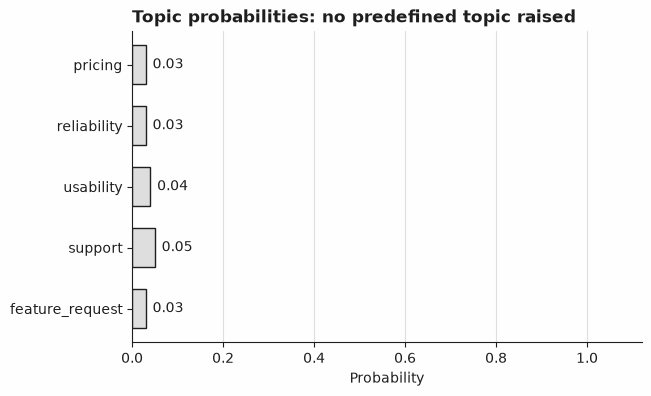

In [4]:
none_example = demo["d02-none"]
none_answer = decide(none_example)
print(none_example.fields["text"])
for label in LABELS:
    print(f"{label}:")
    show_answer(none_answer[label])
plot_answer_probabilities(
    {label: none_answer[label].noul for label in LABELS},
    title="Topic probabilities: no predefined topic raised",
)

Every label's probability of yes sits well below 0.5: nothing here reads as `pricing`, `reliability`, `usability`, `support`, or a `feature_request`, and this example's gold label set — the labels a person has determined the feedback actually carries, used later in "Evaluation" — is empty. Two empty sets match (`exact_set_match`'s definition, used below), so getting this example exactly right means tagging nothing, not nothing at all. `Provenance: synthetic` on every line above says where the answer came from: here always `synthetic`, since nothing in this recipe's fixtures came from a real call; a `recorded` answer would instead name the model the API returned and the date it was captured.

I would pay any price for support this good — the rep fixed my issue in minutes.
pricing:
Noul: 0.42 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
reliability:
Noul: 0.08 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
usability:
Noul: 0.06 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
support:
Noul: 0.83 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
feature_request:
Noul: 0.05 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


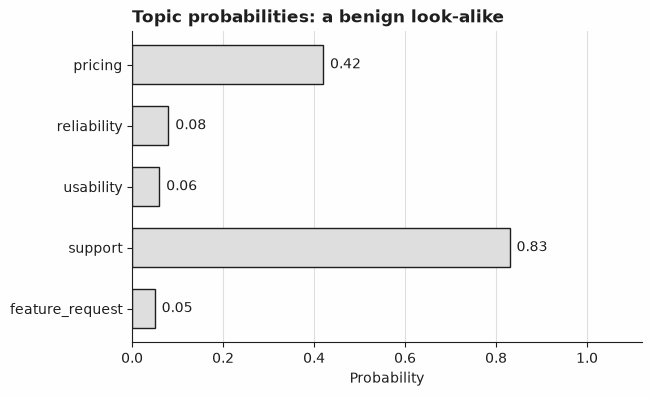

In [5]:
lookalike_example = by_id["v09-lookalike"]
lookalike_answer = decide(lookalike_example)
print(lookalike_example.fields["text"])
for label in LABELS:
    print(f"{label}:")
    show_answer(lookalike_answer[label])
plot_answer_probabilities(
    {label: lookalike_answer[label].noul for label in LABELS},
    title="Topic probabilities: a benign look-alike",
)

The feedback never complains about cost: "pay any price" is a figure of speech praising a support interaction, not a statement about money. Its stored `pricing` probability is still 0.42, noticeably higher than the near-zero values clearly unrelated examples get elsewhere in this fixture set — and only two hundredths below the frozen `pricing` threshold, 0.44, a margin as tight as `t18`'s against `feature_request` below. A word associated with a label, used without the feedback actually raising that label's topic, is a benign look-alike (CONTRIBUTING.md section 5) — not TypeSafe's "literal reading" (S07, item 1), which is about the model reading a question's *instructions* literally, not a surface word in the state it is handed. This stored answer still lands on the right side of 0.5, so it does not flip to a wrong tag by itself; `support`, the topic the feedback is actually about, is confidently true at 0.83. Its "feature" counterpart, `v16-lookalike-wrong`, sits on the *wrong* side of 0.5 (0.80) but the right side of the frozen `feature_request` threshold, 0.82 — correctly left untagged, by exactly the margin that threshold was raised to buy. `v16`'s own sibling in `test`, `t16-lookalike-wrong`, stores two hundredths more, which is enough to cross it (see "Evaluation").

The checkout flow is clunky and the renewal price went up without warning, and now I can't reach anyone on support.
pricing:
Noul: 0.80 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
reliability:
Noul: 0.08 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
usability:
Noul: 0.74 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
support:
Noul: 0.72 probability of yes (0 is no, 1 is yes)
Provenance: synthetic
feature_request:
Noul: 0.05 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


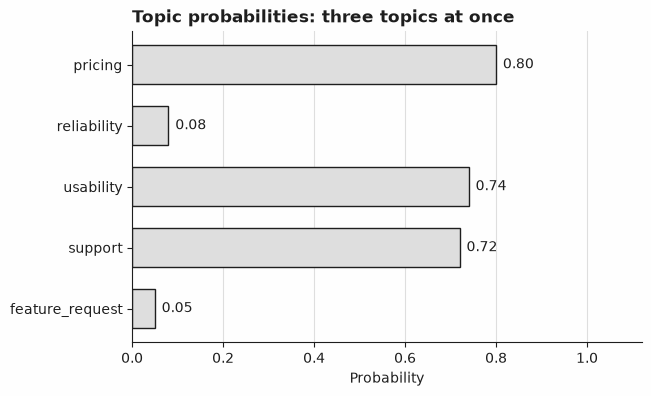

In [6]:
many_example = demo["d01-mixed3"]
many_answer = decide(many_example)
print(many_example.fields["text"])
for label in LABELS:
    print(f"{label}:")
    show_answer(many_answer[label])
plot_answer_probabilities(
    {label: many_answer[label].noul for label in LABELS},
    title="Topic probabilities: three topics at once",
)

Three of the five probabilities sit well above 0.5 here (`pricing`, `usability`, `support`); `reliability` and `feature_request` sit well below. A single five-way `Choice` could only ever report one of these three; five independent `Noul` questions report all three at once, which is the entire reason this recipe does not use `Choice` ("The questions" above).

## Python's part

`decide_tags` in `helpers.py` is Python's rule. For every label it compares the Noul answer's probability against that label's own threshold (the business tag), and separately checks a shared confidence cutoff built from `|2p - 1|` (S03, `jev_cookbook.evaluation.noul_confidence`). Whichever side of the business threshold the probability falls on, a label below the confidence cutoff is not reported as present or absent: it is marked `uncertain` and goes to review instead (CONTRIBUTING.md section 4, "Uncertain or inconsistent results go to an explicit review outcome."). This is the three-path pattern the confidence page (S03) describes for exactly this situation: not every yes-or-no judgment is worth automating outright, and which ones are not is Python's decision, checked by a test for every label and every outcome in `tests/test_helpers.py`, not a sentence of prose.

Two settings are chosen here, both on `validation`, and both frozen before `test` is touched.

- **One business threshold per label.** This recipe's build note says Python applies a per-label threshold, and the five labels are different enough — a `pricing` complaint reads very differently from a vague `usability` gripe — that one shared cut-off would fit some of them badly. Each is chosen with `select_threshold(objective="f1")` on that label's own 19 `validation` examples.
- **One confidence cutoff, shared across all five labels.** With only 19 validation examples, any one label's own subset is too small to trust a second selected parameter. Confidence sits on the same 0-to-1 scale for every label (S03: the Noul formula is the Choice formula applied to a yes-or-no choice), so pooling every (example, label) pair in `validation` — 19 examples times five labels, 95 pairs — gives one usable sample for that one choice instead of five unreliable ones.

Pooling has a real cost, and it is worth naming rather than only defending the idea behind it. `docs/evaluation.md`'s own caution about `noul_confidence` is exactly the one that bites here: `|2p - 1|` is distance from 0.5, not margin at a label's own threshold, so when a threshold sits far from 0.5 — `feature_request`'s is 0.82 — an answer can read as confident while still sitting right on top of the line that actually decides it. Among the `validation` pairs the cutoff chosen below answers, the smallest distance between an answered probability and its own label's threshold is already 0.000 for three of the five labels (`pricing`, `support`, `feature_request`): an answered pair sitting exactly *at* the boundary, as confident-looking as any pair far from it. A cutoff pooled across all five labels cannot tell that `feature_request`'s margin problem is worse than the others; it only ever sees one shared confidence number. "Evaluation" below shows what that costs on `test`.

In [7]:
val_examples = select_split(examples, "validation")
test_examples = select_split(examples, "test")

val_gold = {e.id: set(labels[e.id]) for e in val_examples}
test_gold = {e.id: set(labels[e.id]) for e in test_examples}

val_noul_by_label = {label: [decide(e)[label].noul for e in val_examples] for label in LABELS}
val_gold_by_label = {label: [label in val_gold[e.id] for e in val_examples] for label in LABELS}

thresholds = {
    label: select_threshold(val_gold_by_label[label], val_noul_by_label[label], "f1")
    for label in LABELS
}
for label in LABELS:
    print(f"{label:16s} threshold {thresholds[label]:.4f}{selection}")

pricing          threshold 0.4400 (a selection step, not a reported result)
reliability      threshold 0.4700 (a selection step, not a reported result)
usability        threshold 0.5200 (a selection step, not a reported result)
support          threshold 0.4000 (a selection step, not a reported result)
feature_request  threshold 0.8200 (a selection step, not a reported result)


`threshold_sweep` tries every distinct probability observed on `validation` for one label and reports precision, recall and F1 at each; `select_threshold` picks the one with the highest F1, which is what the printed thresholds above come from, run once per label. The chart below shows that sweep for `usability`: one piece of feedback that only brushes against usability stores 0.58, immediately above the 0.52 a feedback message that genuinely raises it stores, so no threshold separates `validation`'s usability examples perfectly. `select_threshold` resolves that overlap by F1 alone, the same method that chose every other label's threshold above, each from its own, similarly tight, band of validation probabilities near 0.5.

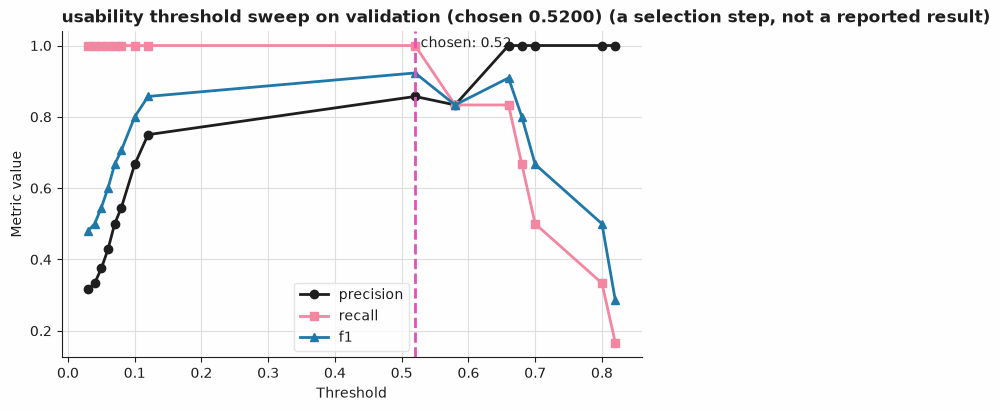

In [8]:
usability_sweep = threshold_sweep(val_gold_by_label["usability"], val_noul_by_label["usability"])
for point in usability_sweep:
    print(
        f"usability validation threshold {point.threshold:.4f}  precision {point.precision:.4f}  "
        f"recall {point.recall:.4f}  f1 {point.f1:.4f}{selection}{check}"
    )
plot_threshold_sweep(
    usability_sweep,
    chosen=thresholds["usability"],
    title=f"usability threshold sweep on validation (chosen {thresholds['usability']:.4f}){check}",
)

With every label's business threshold frozen, the confidence cutoff is chosen next, pooling all 95 validation (example, label) pairs together. `select_confidence_threshold` needs to know, for each pair, whether the business rule (`noul >= threshold`) got that pair right, and how confident the answer was (`noul_confidence`); it then picks the cutoff whose answered subset reaches the target accuracy with the most coverage. Tagging a topic wrong is a low-stakes mistake compared to, say, approving a refund (S03's own example of a high-stakes action needing a stricter gate), so a target of 0.97, not 1.0, is used here: holding out for perfect accuracy on only 95 pooled pairs would mean trusting almost nothing, and a small, deliberately imperfect fixture set like this one should leave a little room for the gate to choose not to catch everything.

Before freezing this cutoff, the confidence page's own caution (S03) is worth checking: confidence is only worth gating on if answers tend to get *less* accurate as the cutoff falls. The risk-and-coverage chart below plots exactly that, on `validation`, before the cutoff is frozen.

pooled validation (example, label) pairs: 95 (a selection step, not a reported result)


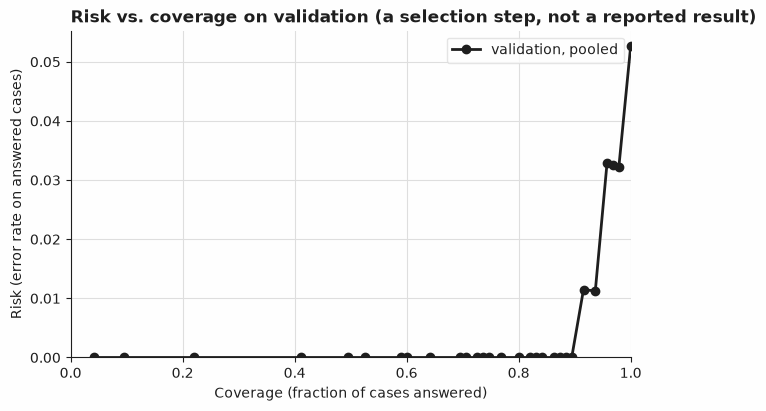

In [9]:
val_correct, val_confidence, _ = pool_label_decisions(
    [e.id for e in val_examples], LABELS, val_gold_by_label, val_noul_by_label, thresholds
)
print(f"pooled validation (example, label) pairs: {len(val_correct)}{selection}")

val_curve = selective_curve(val_correct, val_confidence)
for t, coverage, accuracy, risk in zip(
    val_curve.thresholds, val_curve.coverage, val_curve.accuracy, val_curve.risk, strict=True
):
    print(
        f"validation gate >= {t:.4f}  coverage {coverage:.4f}  accuracy {accuracy:.4f}  "
        f"risk {risk:.4f}{selection}{check}"
    )
plot_risk_coverage(
    val_curve, label="validation, pooled", title=f"Risk vs. coverage on validation{check}"
)

In [10]:
confidence_cutoff = select_confidence_threshold(val_correct, val_confidence, target_accuracy=0.97)
print(f"chosen confidence cutoff, frozen from here on: {confidence_cutoff:.4f}{selection}")

chosen confidence cutoff, frozen from here on: 0.1200 (a selection step, not a reported result)


Applying both frozen settings to the three feedback messages shown in "One answer up close" shows two of the three outcomes `decide_tags` can produce: every label on all three examples is confident enough to answer, so each lands as a `yes` or a `no`, never `uncertain`. The third path, `uncertain`, is not luck here; none of these three examples' probabilities happen to be among the six low-confidence (example, label) pairs the cutoff was chosen to catch. The next two cells build the `uncertain` path's queue from the full `validation` and `test` splits, where it does fire.

In [11]:
for shown_example, shown_answer in (
    (none_example, none_answer),
    (lookalike_example, lookalike_answer),
    (many_example, many_answer),
):
    decisions = helpers.decide_tags(shown_answer, thresholds, confidence_cutoff)
    tags = sorted(helpers.tag_set(decisions))
    review = list(helpers.uncertain_labels(decisions))
    print(f"{shown_example.id}: tags={tags} uncertain={review}")

d02-none: tags=[] uncertain=[]
v09-lookalike: tags=['support'] uncertain=[]
d01-mixed3: tags=['pricing', 'support', 'usability'] uncertain=[]


Every label marked `uncertain`, for every scored example, goes into a `jev_cookbook.simulation.ReviewQueue`: a simulated queue that records what was flagged and why, and does nothing else with it (CONTRIBUTING.md section 4, "Actions are simulated."). `val_results` and `test_results` below hold every example's full set of label decisions; they are built once here and reused, not recomputed, in "Evaluation".

In [12]:
def decisions_for(chosen_examples):
    return {
        e.id: helpers.decide_tags(decide(e), thresholds, confidence_cutoff) for e in chosen_examples
    }


val_results = decisions_for(val_examples)
test_results = decisions_for(test_examples)

review_queue = ReviewQueue()
for split_name, split_examples, split_results in (
    ("validation", val_examples, val_results),
    ("test", test_examples, test_results),
):
    for e in split_examples:
        decisions = split_results[e.id]
        for label in helpers.uncertain_labels(decisions):
            review_queue.submit(
                {"split": split_name, "feedback_id": e.fields["feedback_id"], "label": label},
                decisions[label].reason,
                answer=decide(e)[label],
            )

val_queue_items = [item for item in review_queue.pending() if item.item["split"] == "validation"]
test_queue_items = [item for item in review_queue.pending() if item.item["split"] == "test"]
print(f"items sent to review, validation: {len(val_queue_items)}{selection}")
print(f"items sent to review, test: {len(test_queue_items)}{check}")
for item in review_queue.pending():
    label = selection if item.item["split"] == "validation" else check
    print(f"{item.item} - {item.reason}{label}")

items sent to review, validation: 6 (a selection step, not a reported result)
items sent to review, test: 0 (a pipeline check, not a Jev result)
{'split': 'validation', 'feedback_id': 'FB-101', 'label': 'pricing'} - confidence below the review cutoff (a selection step, not a reported result)
{'split': 'validation', 'feedback_id': 'FB-101', 'label': 'reliability'} - confidence below the review cutoff (a selection step, not a reported result)
{'split': 'validation', 'feedback_id': 'FB-102', 'label': 'support'} - confidence below the review cutoff (a selection step, not a reported result)
{'split': 'validation', 'feedback_id': 'FB-105', 'label': 'feature_request'} - confidence below the review cutoff (a selection step, not a reported result)
{'split': 'validation', 'feedback_id': 'FB-114', 'label': 'reliability'} - confidence below the review cutoff (a selection step, not a reported result)
{'split': 'validation', 'feedback_id': 'FB-117', 'label': 'usability'} - confidence below the revie

## Evaluation

Both settings were chosen and frozen above, on `validation`. This section reports what the frozen rule does on `test`, and nothing below reimplements `noul >= threshold` or the confidence check by hand: the tag set comes from `jev_cookbook.evaluation.multilabel_from_noul` with the frozen thresholds, and the confidence gate's numbers come from `test_results`, built by `decide_tags` above. It is split into the two things a multi-label `Noul` recipe needs to show separately:

- **The tag set itself**, from the business rule alone (`noul >= threshold`, ignoring the confidence gate, exactly as `multilabel_from_noul` applies the frozen per-label thresholds): per-label precision, recall and F1, their micro and macro summaries, and the share of examples tagged exactly right.
- **The confidence gate's own coverage, accuracy and risk**, counted directly from `decide_tags`'s three outcomes with `jev_cookbook.evaluation.pool_label_outcomes` fed to `evaluate_outcomes`, rather than from a second call to `jev_cookbook.evaluation.evaluate_selective`. Here that is arithmetically the same split either way — `decide_tags` has only one review branch, the confidence gate, so `evaluate_selective` on `pool_label_decisions`'s pooled correct/confidence agrees with `evaluate_outcomes` on `pool_label_outcomes`'s pooled accepted/correct to four decimals. Counting from the rule is still the right habit to keep: every number stays traceable to the `decide_tags` call the reader just read about, with no second comparison to keep in sync, and the habit pays off directly for a rule with more than one review branch (a fallback option, a foreign value), where the two would *not* agree.

**Terms, as they are used below:** *precision* is, of the examples the business rule tagged with a label, the fraction that really carry it; *recall* is, of the examples that really carry a label, the fraction the rule tagged; *f1* is their harmonic mean, low whenever either one is; *support* is how many `test` examples really carry that label, so a recall figure is only as meaningful as its support is large; *micro* pools every label's counts together before computing one precision, recall and F1, so a frequent label dominates; *macro* averages each label's own score equally, so a rare label counts as much as a frequent one; *coverage* is the fraction of (example, label) pairs the confidence gate answered rather than sent to review; *risk* is `1 - accuracy` among those it answered.

In [13]:
test_noul_by_label = {label: [decide(e)[label].noul for e in test_examples] for label in LABELS}
business_predicted = multilabel_from_noul(test_noul_by_label, thresholds)
test_gold_sets = [frozenset(test_gold[e.id]) for e in test_examples]

metrics = multilabel_metrics(test_gold_sets, business_predicted, labels=LABELS)
for label in LABELS:
    counts = metrics["per_label"][label]
    print(
        f"{label:16s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )
print(
    f"micro  precision {metrics['micro']['precision']:.3f}  "
    f"recall {metrics['micro']['recall']:.3f}  f1 {metrics['micro']['f1']:.3f}{check}"
)
print(
    f"macro  precision {metrics['macro']['precision']:.3f}  "
    f"recall {metrics['macro']['recall']:.3f}  f1 {metrics['macro']['f1']:.3f}{check}"
)

exact = exact_set_match(test_gold_sets, business_predicted)
print(f"exact label-set match: {exact:.3f}{check}")

pricing          precision 1.000  recall 1.000  f1 1.000  support 7 (a pipeline check, not a Jev result)
reliability      precision 1.000  recall 1.000  f1 1.000  support 5 (a pipeline check, not a Jev result)
usability        precision 1.000  recall 1.000  f1 1.000  support 5 (a pipeline check, not a Jev result)
support          precision 1.000  recall 1.000  f1 1.000  support 5 (a pipeline check, not a Jev result)
feature_request  precision 0.667  recall 0.667  f1 0.667  support 3 (a pipeline check, not a Jev result)
micro  precision 0.960  recall 0.960  f1 0.960 (a pipeline check, not a Jev result)
macro  precision 0.933  recall 0.933  f1 0.933 (a pipeline check, not a Jev result)
exact label-set match: 0.895 (a pipeline check, not a Jev result)


`feature_request`'s `test` precision *and* recall are both 0.667, and two different examples, one on each side of the frozen 0.82 threshold, explain why. `t16-lookalike-wrong` ("Finally! The new bulk-export feature request we filed last year shipped.") stores 0.82, at the threshold, even though its gold label set is empty — the feedback only references a past request, not a current one — so it is tagged `feature_request` anyway: a false positive. `t18` ("Add an undo button, please — I just lost an hour of work when the app crashed.", gold `{feature_request, reliability}`) stores 0.80, two hundredths below that same threshold, so a genuine feature request is missed: a false negative. The threshold was pushed up to 0.82 on `validation` specifically to keep `v16-lookalike-wrong`'s 0.80 out ("Python's part" above); `t18`'s 0.80 is that same choice costing a real feature request on a split the threshold was never tuned against.

In [14]:
def outcomes_for(chosen_examples, results, gold_by_label):
    """Coverage, accuracy and risk of decide_tags's own yes/no outcomes, pooled over every
    label with jev_cookbook.evaluation.pool_label_outcomes and evaluate_outcomes -- never a
    separate reimplementation of ``noul >= threshold`` or the confidence check."""
    accepted_by_label = {
        label: [results[e.id][label].outcome != helpers.UNCERTAIN for e in chosen_examples]
        for label in LABELS
    }
    tag_by_label = {label: [results[e.id][label].tag for e in chosen_examples] for label in LABELS}
    accepted, correct, _ = pool_label_outcomes(
        [e.id for e in chosen_examples], LABELS, gold_by_label, accepted_by_label, tag_by_label
    )
    return evaluate_outcomes(accepted, correct)


test_gold_by_label = {label: [label in test_gold[e.id] for e in test_examples] for label in LABELS}

val_outcomes = outcomes_for(val_examples, val_results, val_gold_by_label)
print(f"(example, label) pairs on validation: {val_outcomes.n_total}{selection}")
print(
    f"answered: {val_outcomes.n_answered} of {val_outcomes.n_total} "
    f"(coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")

test_outcomes = outcomes_for(test_examples, test_results, test_gold_by_label)
print(f"(example, label) pairs on test: {test_outcomes.n_total}{check}")
print(
    f"answered: {test_outcomes.n_answered} of {test_outcomes.n_total} "
    f"(coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")

(example, label) pairs on validation: 95 (a selection step, not a reported result)
answered: 89 of 95 (coverage 0.9368) (a selection step, not a reported result)
accuracy among those answered: 0.9888 (a selection step, not a reported result)
risk among those answered: 0.0112 (a selection step, not a reported result)
(example, label) pairs on test: 95 (a pipeline check, not a Jev result)
answered: 95 of 95 (coverage 1.0000) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9789 (a pipeline check, not a Jev result)
risk among those answered: 0.0211 (a pipeline check, not a Jev result)


On `validation`, the gate routes 6 of the 95 pairs to review and answers the rest at 0.9888 accuracy, close to the 0.97 target it was chosen for (chosen from only 95 pooled pairs, so the accuracy it actually reaches does not land exactly on the target it aimed for). On `test`, nothing is routed to review at all, and `test` risk, 0.0211, is both of `test`'s wrong pairs (`t16-lookalike-wrong`'s false positive and `t18`'s false negative, discussed above) over 95. Neither is a low-confidence pair the gate was ever built to catch: `t16`'s 0.82 gives it confidence 0.64, and `t18`'s 0.80 gives it 0.60, both comfortably clear of the 0.12 cutoff. This is not a coincidence the cutoff happened to miss; it is the pooling caveat from "Python's part" showing up exactly where it was predicted to: `feature_request`'s threshold sits at 0.82, far from 0.5, so an answer can be `noul_confidence`-confident while still sitting on top of the line that decides it, and a cutoff pooled across all five labels has no way to single out the one label where that is happening. A cutoff chosen for high accuracy on a handful of ambiguous `validation` pairs is a guarantee about those pairs, not about any pair this recipe has not seen, confident or not.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the per-label thresholds, the shared confidence cutoff, the review queue and the evaluation above behave as designed on 38 scored feedback messages (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. Every stored probability in the offline run was written by hand, some deliberately wrong on purpose — the two literal-reading lookalikes discussed above — so every number above describes this fixture set and not a model.

In [15]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(
        f"N: {len(scored)} scored examples ({len(val_examples)} validation, {len(test_examples)} test)"
    )

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a sixth label to `LABELS` in `helpers.py` **and add it to the gold set of every example that actually raises it**, regenerate the fixtures (`python build_fixtures.py` after extending `ROWS` with a probability and an updated gold set for every example), and watch a new row appear in every per-label table above. Skipping the gold-set update is instructive on its own, not just broken: every example then has the new label gold-`False` by default, `select_threshold` has no true example to separate from and returns the highest observed probability, and the pooled cutoff and the review queue swing accordingly.
- Loosen `target_accuracy` in the confidence-cutoff cell above (for example to `0.90`) and see the review queue shrink as coverage rises.
- Neighbouring recipes: [`02-refund-intent-detection`](../02-refund-intent-detection/) and [`10-answer-relevance-check`](../10-answer-relevance-check/), two other `Noul` recipes with a single proposition each, to contrast with this recipe's five independent ones; and [`05-document-classification`](../05-document-classification/), a `Choice` over a fixed option set, for the one-label case "The questions" above explains why this recipe does not use.